In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

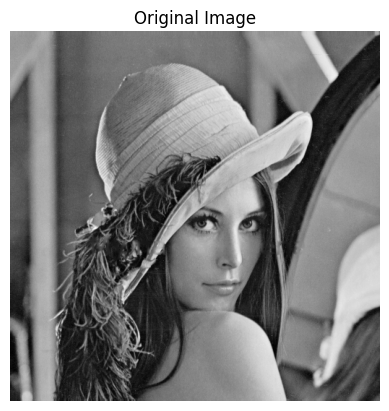

In [ ]:
image_path = '../../input.jpg'
image_color = cv2.imread(image_path)

# Fallback to a synthetic test image if input isn't found
if image_color is None:
    h, w = 256, 256
    image_color = np.zeros((h, w, 3), dtype=np.uint8)
    # Create a simple synthetic pattern: rectangles with different intensities
    image_color[: h//2, : w//2] = (40, 40, 40)
    image_color[: h//2, w//2 :] = (120, 120, 120)
    image_color[h//2 :, : w//2] = (200, 200, 200)
    image_color[h//2 :, w//2 :] = (80, 80, 80)

image = cv2.cvtColor(image_color, cv2.COLOR_BGR2GRAY)

plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

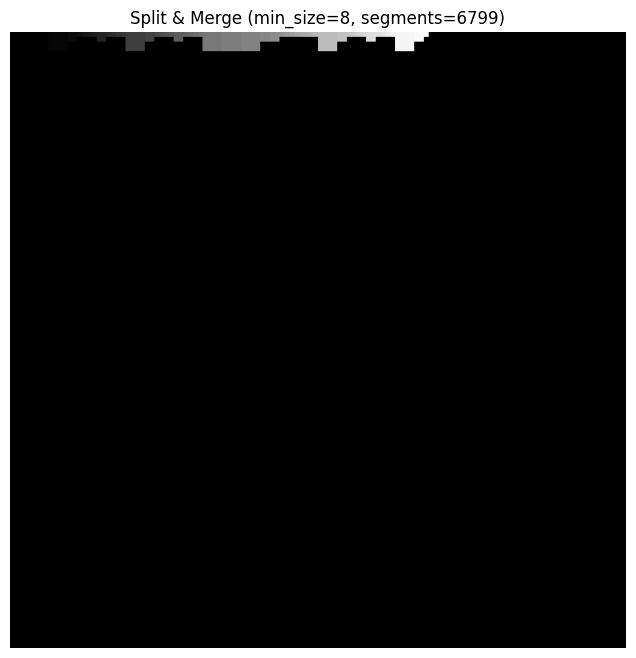

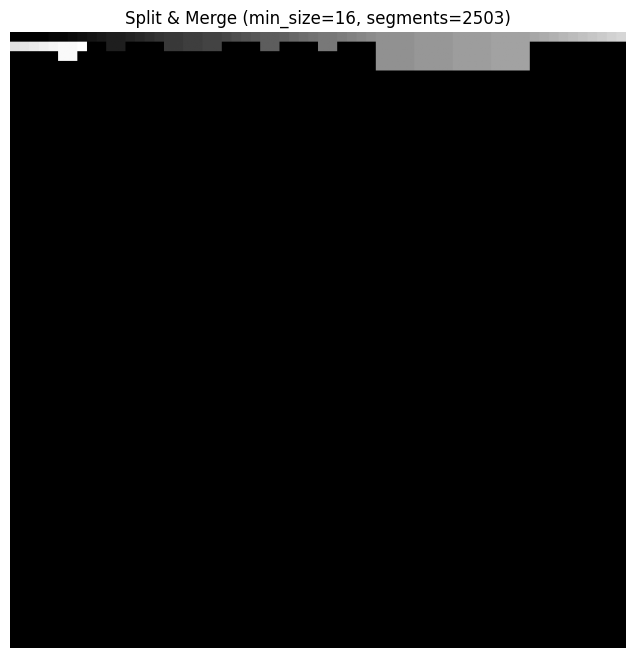

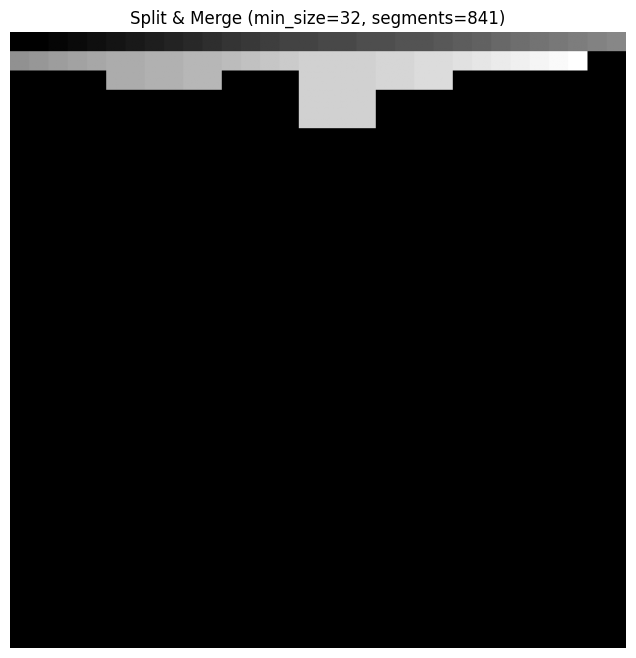

In [ ]:
def is_uniform(region: np.ndarray, tolerance: float = 10.0) -> bool:
    # Use std-dev as homogeneity criterion
    return float(np.std(region)) < tolerance


def split_quadtree(image: np.ndarray, min_size: int, max_depth: int = 10, tol: float = 10.0):
    """
    Recursively split the image into a quadtree based on a homogeneity criterion.

    Returns a list of nodes: each node is a dict with keys
      - 'y', 'x', 'h', 'w' (coordinates in the original image)
      - 'region' (view of the image)
    """
    H, W = image.shape
    nodes = []

    def split(y, x, h, w, depth):
        region = image[y:y+h, x:x+w]
        if depth >= max_depth or h <= min_size or w <= min_size or is_uniform(region, tol):
            nodes.append({"y": y, "x": x, "h": h, "w": w, "region": region})
            return
        # split into four quadrants (handle odd sizes robustly)
        h2 = h // 2
        w2 = w // 2
        # Ensure non-zero sizes
        if h2 == 0 or w2 == 0:
            nodes.append({"y": y, "x": x, "h": h, "w": w, "region": region})
            return
        split(y, x, h2, w2, depth + 1)
        split(y, x + w2, h2, w - w2, depth + 1)
        split(y + h2, x, h - h2, w2, depth + 1)
        split(y + h2, x + w2, h - h2, w - w2, depth + 1)

    split(0, 0, H, W, 0)
    return nodes


def _horizontal_merge(nodes, tol: float):
    by_row = {}
    for n in nodes:
        by_row.setdefault(n['y'], []).append(n)
    for y in by_row:
        by_row[y].sort(key=lambda n: n['x'])

    merged_rows = []
    changed = False
    for y, row_nodes in by_row.items():
        stack = []
        for n in row_nodes:
            if stack:
                prev = stack[-1]
                if prev['y'] == n['y'] and prev['h'] == n['h'] and prev['x'] + prev['w'] == n['x']:
                    if abs(float(np.mean(prev['region'])) - float(np.mean(n['region']))) <= tol:
                        prev['w'] += n['w']
                        prev['region'] = np.hstack((prev['region'], n['region']))
                        changed = True
                        continue
            stack.append({**n})
        merged_rows.extend(stack)
    return merged_rows, changed


def _vertical_merge(nodes, tol: float):
    by_col = {}
    for n in nodes:
        by_col.setdefault(n['x'], []).append(n)
    for x in by_col:
        by_col[x].sort(key=lambda n: n['y'])

    final_nodes = []
    changed = False
    for x, col_nodes in by_col.items():
        stack = []
        for n in col_nodes:
            if stack:
                prev = stack[-1]
                if prev['x'] == n['x'] and prev['w'] == n['w'] and prev['y'] + prev['h'] == n['y']:
                    if abs(float(np.mean(prev['region'])) - float(np.mean(n['region']))) <= tol:
                        prev['h'] += n['h']
                        prev['region'] = np.vstack((prev['region'], n['region']))
                        changed = True
                        continue
            stack.append({**n})
        final_nodes.extend(stack)
    return final_nodes, changed


def merge_adjacent(nodes, tol: float = 10.0, max_passes: int = 10):
    """
    Merge adjacent blocks if their mean intensities are similar.
    Iteratively apply horizontal and vertical passes until convergence or max_passes.
    """
    cur = nodes
    for _ in range(max_passes):
        cur, c1 = _horizontal_merge(cur, tol)
        cur, c2 = _vertical_merge(cur, tol)
        if not (c1 or c2):
            break
    return cur


def split_and_merge(image: np.ndarray, min_size: int, tol: float = 10.0, max_depth: int = 10):
    nodes = split_quadtree(image, min_size=min_size, max_depth=max_depth, tol=tol)
    merged = merge_adjacent(nodes, tol=tol)
    return merged


# Try different minimum sizes
min_sizes = [8, 16, 32]
tolerance = 12.0

fig, axes = plt.subplots(1, len(min_sizes) + 1, figsize=(5 * (len(min_sizes) + 1), 5))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

for i, min_sz in enumerate(min_sizes, start=1):
    nodes = split_and_merge(image, min_size=min_sz, tol=tolerance)

    # Visualize: fill each merged block with its mean intensity
    vis = np.zeros_like(image, dtype=np.float32)
    for n in nodes:
        m = float(np.mean(n['region']))
        y, x, h, w = n['y'], n['x'], n['h'], n['w']
        vis[y:y+h, x:x+w] = m
    vis = np.clip(vis, 0, 255).astype(np.uint8)

    axes[i].imshow(vis, cmap='gray')
    axes[i].set_title(f'min_size={min_sz}\nblocks={len(nodes)}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()